# Moral Foundation classification of Twitter Text
- Next step of the Morality based sentimental analysis. Text is tockenized using TF-IDF vectorization and BERT and lstm and BERT-Base-uncased for classification


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score,precision_recall_fscore_support
from sklearn.model_selection import train_test_split,KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
import torch.optim as optim
from transformers import pipeline, BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments,BertPreTrainedModel, BertConfig,BertModel, AutoTokenizer,get_scheduler
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler, Subset
from sklearn.preprocessing import LabelEncoder
import torch
import torch.nn as nn
import requests
import os
from torch.utils.data import TensorDataset
import zipfile

In [2]:
# Load dataset from CSV file
file_path = "/content/updated_data.csv"  # Replace with the actual file path
df = pd.read_csv(file_path, encoding = "ISO-8859-1")

# Display the first few rows of the dataset
print(df.head())

  Corpus                                         Tweet Text  Stance Foundation
0    EVM  #EVMs are easy to manipulate . This was demons...      -1   fairness
1    CAA             Congratulations\nCAA  is arrived  #CAA       1    loyalty
2    CAA  My dear Indian muslims we are 35 crores of pop...      -1    loyalty
3    CAA  This guy was part of anti Hindu protests in th...       0   fairness
4    CAA  Woman protester breaks down while speaking to ...       0       care


In [3]:
# Find the number of rows for each unique value in the first column
class_counts = df.iloc[:, 0].value_counts()

# Print the counts for each class
print("Number of rows for each class:")
print(class_counts)

# Print the total number of rows
total_rows = df.shape[0]
print("\nTotal number of rows:", total_rows)

Number of rows for each class:
Corpus
EVM                     904
Animal Sacrifices       882
Anti Conversion Laws    882
LGBTQ                   860
CAA                     855
UCC                     828
Brain Drain             800
Name: count, dtype: int64

Total number of rows: 6011


In [4]:
df = df[df["Foundation"].notna()]

In [5]:
df.head()
data = df

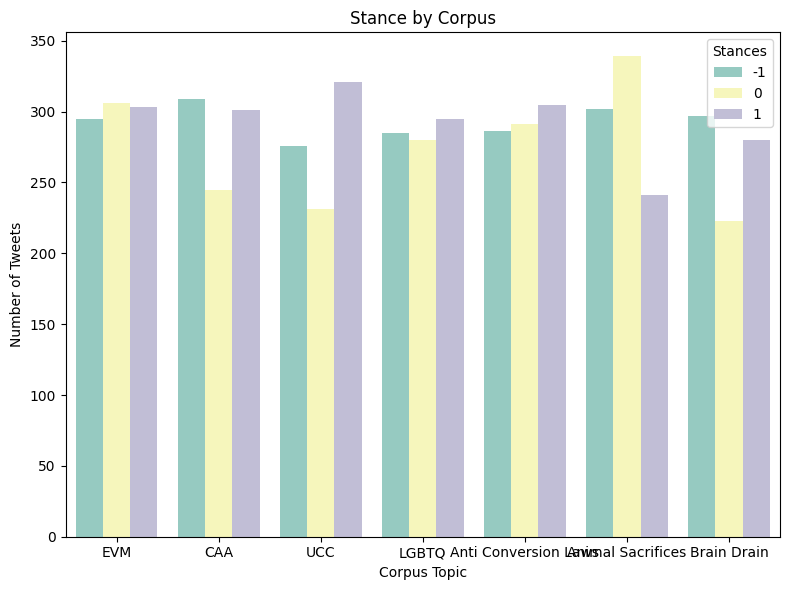

In [6]:
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='Corpus', hue='Stance', palette='Set3')
plt.title('Stance by Corpus')
plt.ylabel('Number of Tweets')
plt.xlabel('Corpus Topic')
plt.legend(title='Stances')
plt.tight_layout()
plt.show()

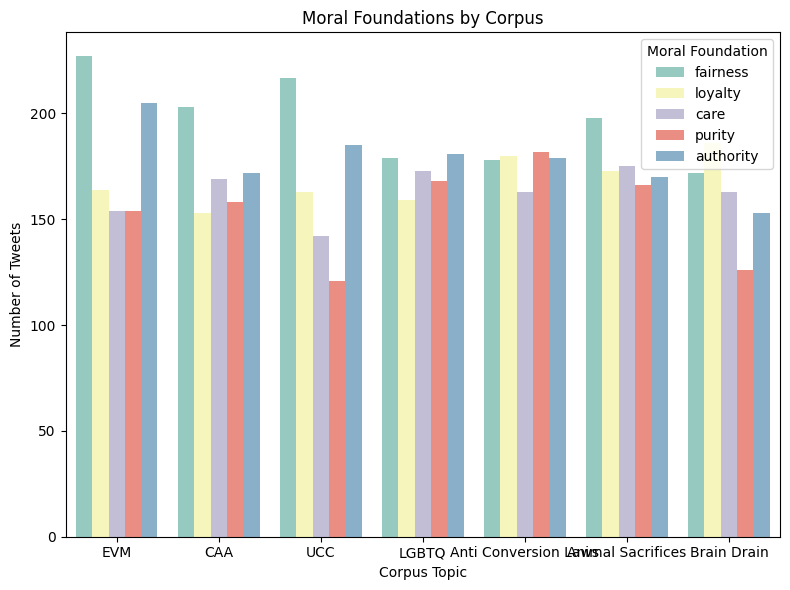

In [7]:
plt.figure(figsize=(8, 6))
sns.countplot(data=data, x='Corpus', hue='Foundation', palette='Set3')
plt.title('Moral Foundations by Corpus')
plt.ylabel('Number of Tweets')
plt.xlabel('Corpus Topic')
plt.legend(title='Moral Foundation')
plt.tight_layout()
plt.show()

<ipython-input-8-a904c2adccf4>:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
<ipython-input-8-a904c2adccf4>:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
<ipython-input-8-a904c2adccf4>:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


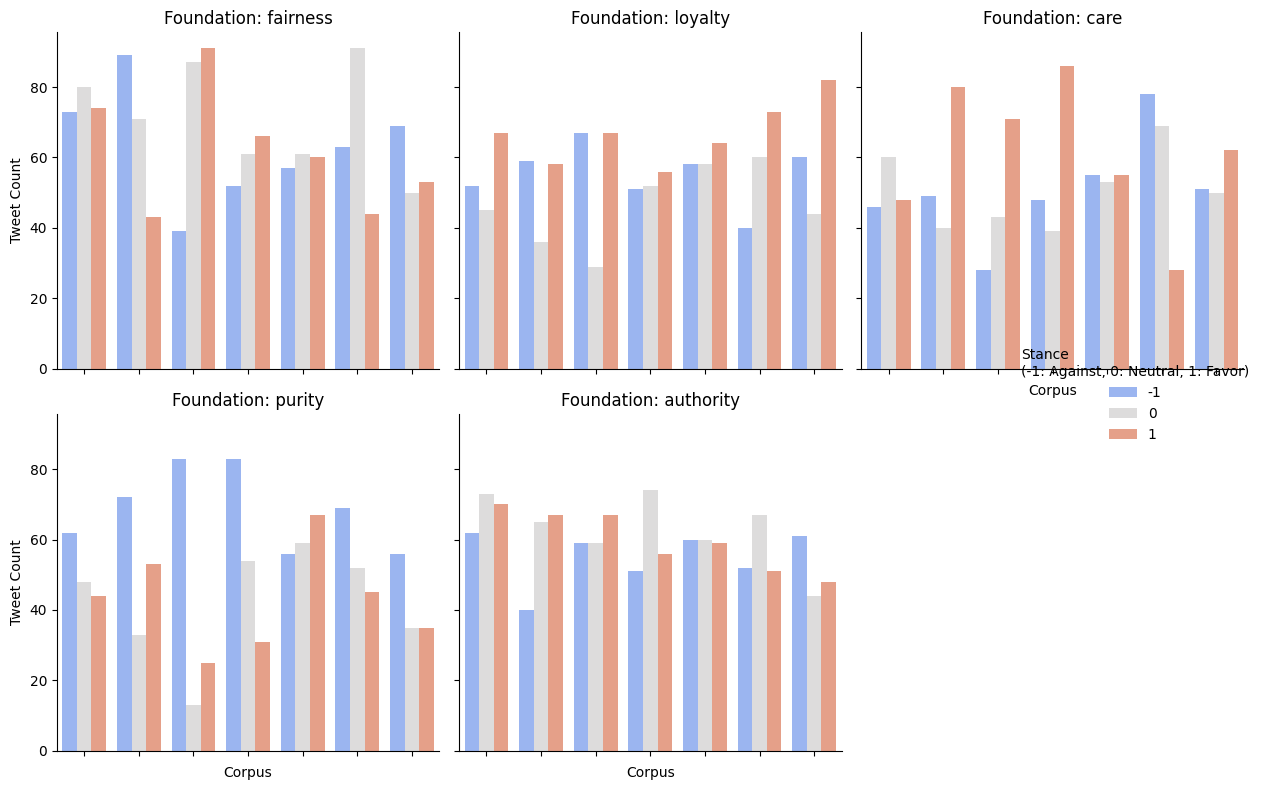

In [ ]:
stance_order = [-1, 0, 1]
df['Stance'] = pd.Categorical(df['Stance'], categories=stance_order, ordered=True)

# Plot with layout improvements
g = sns.catplot(
    data=df, kind="count",
    x="Corpus", hue="Stance",
    col="Foundation", col_wrap=3,
    palette="coolwarm", height=4, aspect=1
)

# Rotate x-tick labels for visibility
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Fix axis labels and legend
g.set_titles("Foundation: {col_name}", size=12)
g.set_axis_labels("Corpus", "Tweet Count")
g._legend.set_title("Stance\n(-1: Against, 0: Neutral, 1: Favor)")

# Adjust spacing between subplots
plt.subplots_adjust(top=0.9, hspace=0.5, wspace=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Preprocess the data
X = df['Tweet Text']
y = df['Foundation']

In [9]:
print(y)

0        fairness
1         loyalty
2         loyalty
3        fairness
4            care
          ...    
6006         care
6007       purity
6008     fairness
6009    authority
6010      loyalty
Name: Foundation, Length: 6011, dtype: object


# Bert Model
- The data set is limited(1213 Tweets).
- Model is designed with bert as encoder and fully connected layers as classifier
- Performing K(5 here) fold cross validation for analyzing the performance of the model on the dataset.

In [ ]:
# Model Setup
class CustomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        label = self.labels[item]
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
class BertForMoralFoundation(BertPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.bert = BertModel(config)
        self.dropout = nn.Dropout(0.3)  # Reduce dropout

        # self.fc1 = nn.Linear(config.hidden_size, 512)  # One small FC layer
        # self.relu = nn.ReLU()
        self.classifier = nn.Linear(config.hidden_size, 5)  # Output layer

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, labels=None):
        outputs = self.bert(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        pooled_output = outputs.pooler_output  # [CLS] token representation

        x = self.dropout(pooled_output)
        # x = self.fc1(x)
        # x = self.relu(x)

        logits = self.classifier(x)  # Final predictions

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits}


In [ ]:
losses_main, accuracies_main, precisions_main, recalls_main, f1_scores_main = [], [], [], [], []

In [ ]:
def k_fold_cross_validation(model, dataset, texts, label_encoder, k=7, batch_size=8, epochs=3, lr=2e-5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    losses, accuracies, precisions, recalls, f1_scores = [], [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
        print(f"\nFold {fold+1}/{k}")

        # Create dataset subsets instead of samplers
        train_dataset = Subset(dataset, train_idx)
        val_dataset = Subset(dataset, val_idx)

        # Define training arguments
        training_args = TrainingArguments(
            output_dir=f"./results/fold{fold}",
            num_train_epochs=epochs,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            eval_strategy="epoch",
            save_strategy="no",
            learning_rate=lr,
            weight_decay=0.1,
            logging_dir="./logs",
            logging_steps=10
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset
        )

        # Train & Evaluate
        trainer.train()
        eval_result = trainer.evaluate()
        losses.append(eval_result["eval_loss"])

        # Predictions & Labels
        all_preds, all_labels, misclassified_samples = [], [], []

        model.eval()
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        with torch.no_grad():
            for batch_idx, batch in enumerate(val_loader):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["label"].to(device)

                outputs = model(input_ids, attention_mask=attention_mask)
                logits = outputs["logits"]  # BERT outputs logits
                preds = torch.argmax(logits, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                # Store misclassified samples
                for i, (pred, true) in enumerate(zip(preds, labels)):
                    if pred != true:
                        misclassified_samples.append((texts[val_idx[batch_idx * batch_size + i]], true.item(), pred.item()))

        # Compute Metrics
        accuracy = accuracy_score(all_labels, all_preds)
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted", zero_division=0)

        accuracies.append(accuracy)
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

        print(f"Fold {fold+1} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

        # Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        print(f"Misclassifications per Class (Actual → Predicted):\n{cm - np.diag(np.diag(cm))}")

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=list(label_encoder.classes_), yticklabels=list(label_encoder.classes_))
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix - Fold {fold+1}")
        plt.show()

        # Print some misclassified tweets
        print("\nMisclassified Tweets:")
        for text, true, pred in misclassified_samples[:5]:  # Show first 5 misclassified examples
            print(f" Tweet: \"{text}\" | True: {true} | Predicted: {pred}")
    losses_main.append(losses)
    accuracies_main.append(accuracies)
    precisions_main.append(precisions)
    recalls_main.append(recalls)
    f1_scores_main.append(f1_scores)
    # Print Final Averages
    print(f"\nFinal Results Across {k} Folds:")
    print(f"Avg Loss: {np.mean(losses):.4f}")
    print(f"Avg Accuracy: {np.mean(accuracies):.4f}")
    print(f"Avg Precision: {np.mean(precisions):.4f}")
    print(f"Avg Recall: {np.mean(recalls):.4f}")
    print(f"Avg F1-Score: {np.mean(f1_scores):.4f}")

In [ ]:
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
#label encodings for moral foundations
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [ ]:
MAX_LEN = 128
bert_train_dataset = CustomDataset(X.tolist(), y.tolist(), bert_tokenizer, MAX_LEN)
# bert_test_dataset = CustomDataset(X_test.tolist(), y_test.tolist(), bert_tokenizer, MAX_LEN)

In [ ]:
bert_labels, bert_preds = [],[]
def evaluate_on_test(model, test_dataset, batch_size=8):
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    # Store predictions & true labels

    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs["logits"]
            preds = torch.argmax(logits, dim=1)

            bert_preds.extend(preds.cpu().numpy())
            bert_labels.extend(labels.cpu().numpy())



In [ ]:
config = BertConfig.from_pretrained("bert-base-uncased", num_labels=5)
model = BertForMoralFoundation.from_pretrained("bert-base-uncased", config=config)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForMoralFoundation were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

BertForMoralFoundation(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, el

In [ ]:
text = df["Tweet Text"].tolist()

In [ ]:
print(label_encoder.classes_)

['authority' 'care' 'fairness' 'loyalty' 'purity']


In [ ]:
torch.cuda.empty_cache()


Fold 1/7


wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nlvmadhavca3 (nlvmadhavca3-vasavi-college-of-engineering) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss
1,1.187000,1.112854
2,0.988400,1.109427
3,0.680700,1.133037


Fold 1 - Accuracy: 0.5925, Precision: 0.5940, Recall: 0.5925, F1-score: 0.5921
Misclassifications per Class (Actual → Predicted):
[[ 0 16 21 19  9]
 [16  0 34 15  5]
 [32 19  0 16 10]
 [21 17 13  0 20]
 [17 19 14 17  0]]


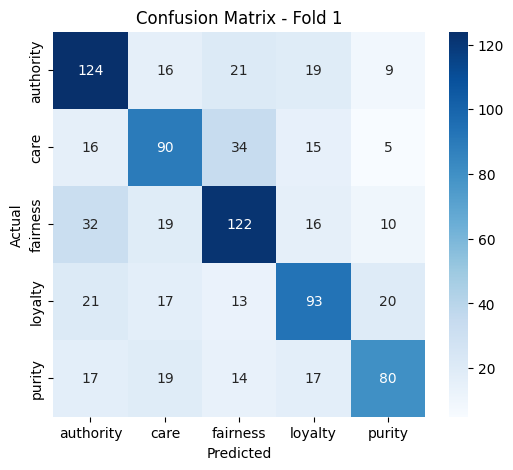


Misclassified Tweets:
 Tweet: "In the freezing cold of December, the women of Shaheen bagh keep vigil under blankets, their infants in a huddle under one arm, as men distribute chai and boiled eggs. It's 17th night of this women led vigil against #CAA #NRC. The Tiranga is at the centre #ShaheenBagh" | True: 1 | Predicted: 3
 Tweet: "Dark day for India. 

A religion-based citizenship test is antithetical to the secular constitutional foundations of the republic, and I will fight against this legally and politically with all my might.

#CAA #MNMagainstCAA #CAANotification" | True: 2 | Predicted: 4
 Tweet: "Modi himself raised serious concern about EVM during the 2014 LS election. What happened to his stand now ? Will the media share this clip to Modi ask his stand ?@narendramodi #EVM" | True: 0 | Predicted: 3
 Tweet: "The #EVM scam !Why should it be treated as a holy black box ? We need openness and transparency" | True: 2 | Predicted: 4
 Tweet: "In my POV, If BJP could really manipulat

Epoch,Training Loss,Validation Loss
1,0.674500,0.671246
2,0.581500,0.658472
3,0.188400,0.741269


Fold 2 - Accuracy: 0.7765, Precision: 0.7777, Recall: 0.7765, F1-score: 0.7766
Misclassifications per Class (Actual → Predicted):
[[ 0  7 10  6 10]
 [ 6  0 19 13  6]
 [13 19  0  5  4]
 [12  6  9  0  6]
 [12 13  8  8  0]]


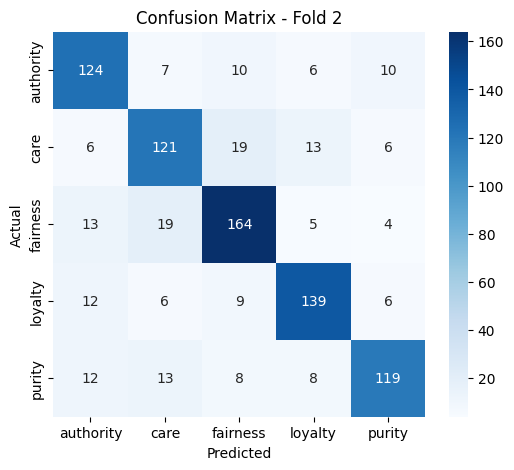


Misclassified Tweets:
 Tweet: "Competing priorities, political realities and delicate balancing between whatÃ¢ÂÂs immediately possible and what could potentially disrupt peace and progress made so far.

#CAA took a while, saw widespread protests and #ShaheenBagh. It didnÃ¢ÂÂt concern a single Indian Muslim." | True: 2 | Predicted: 0
 Tweet: "Occupying PoK is a fancy idea but what about PoK Muslims? 

We canÃ¢ÂÂt give them citizenship now as #CAA is already in force." | True: 1 | Predicted: 2
 Tweet: "Law Commission extended 2 weeks time to seek suggestions on Uniform Civil Code, now deadline will be July 28. As Deadline Nears, Law Commission Receives 46 Lakh Responses on Uniform Civil Code
#UCCDividesIndia #UCC #UCCisNotUniform" | True: 2 | Predicted: 0
 Tweet: "In India, religion is deeply personal, and no law should dictate who someone can or cannot believe in. LetÃ¢ÂÂs stand for freedom of thought and belief" | True: 0 | Predicted: 4
 Tweet: "True devotion doesnÃ¢ÂÂt come

Epoch,Training Loss,Validation Loss
1,0.528900,0.255885
2,0.278100,0.245050
3,0.100900,0.264921


Fold 3 - Accuracy: 0.9430, Precision: 0.9434, Recall: 0.9430, F1-score: 0.9430
Misclassifications per Class (Actual → Predicted):
[[0 3 7 2 2]
 [1 0 6 3 2]
 [2 1 0 1 3]
 [3 0 0 0 6]
 [1 6 0 0 0]]


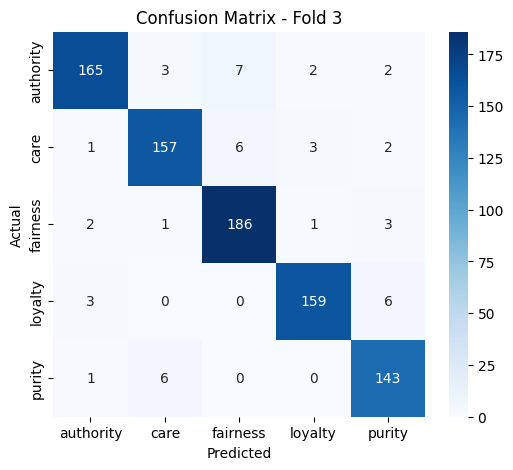


Misclassified Tweets:
 Tweet: "Discrimination is major factor affecting trans+ peopleÃ¢ÂÂs mental health, says study" | True: 0 | Predicted: 1
 Tweet: "Gender Identity Disorder was first set as a diagnosis in the Diagnostic Statistical Manual (used to diagnosis mental illnesses) in 1987. It was changed to Gender Dysphoria in 2013 to erase the stigma attached to the word Disorder. Note the prevalence rate. I wonder if some of those interesting studies have lapsed due to not wanting to find the biological, genetic, or psychological influences that may be causal and perhaps able to be addressed. Note the paragraph that advises the proper course of treatment to make sure the person is doing it for the right reason! And how much higher the success rate was. " | True: 1 | Predicted: 0
 Tweet: "Sacrificing animals for religious reasons is a practice that degrades the sanctity of faith. Compassion is the true essence of religion, and no belief should require the pain of an innocent life" | 

Epoch,Training Loss,Validation Loss
1,0.391400,0.099237
2,0.162500,0.089184
3,0.035600,0.096274


Fold 4 - Accuracy: 0.9825, Precision: 0.9826, Recall: 0.9825, F1-score: 0.9825
Misclassifications per Class (Actual → Predicted):
[[0 1 2 0 0]
 [0 0 0 0 0]
 [2 1 0 0 2]
 [2 1 0 0 1]
 [1 0 2 0 0]]


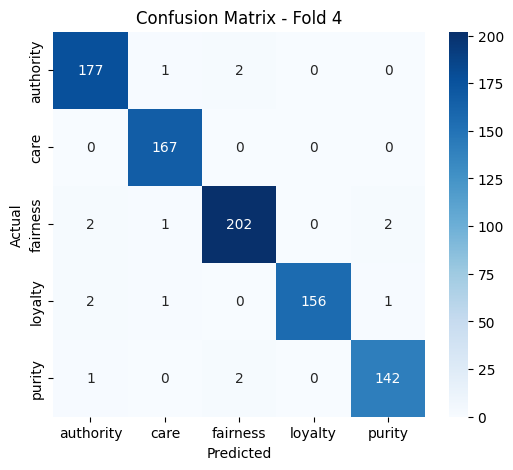


Misclassified Tweets:
 Tweet: "Dear Modi govt, withdraw present #CAA and if you must have it, redraft it substantially. Take out these words :Ã¢ÂÂHindu, Sikh, Buddhist, Jain, Parsi, Christian.Ã¢ÂÂ Replace with these words: Ã¢ÂÂpersecuted religious minorities.Ã¢ÂÂ Ã°ÂÂÂ#CAA_NRC_Protests" | True: 2 | Predicted: 0
 Tweet: "If there are to be North East specific #CAA rules, what happened to the One Nation, One Law motto that drove decisions in #Kashmir?" | True: 4 | Predicted: 2
 Tweet: "Election Commission must answer allegations of discrepancies in EVM results. #FairElections" | True: 3 | Predicted: 0
 Tweet: "VVPAT verification can ensure EVM credibility. Let's work towards better elections. #Transparency" | True: 4 | Predicted: 2
 Tweet: "The government should protect religious customs, including Animal Sacrifices." | True: 2 | Predicted: 0

Fold 5/7


Epoch,Training Loss,Validation Loss
1,0.229100,0.080895
2,0.047000,0.099652
3,0.053400,0.098042


Fold 5 - Accuracy: 0.9849, Precision: 0.9851, Recall: 0.9849, F1-score: 0.9849
Misclassifications per Class (Actual → Predicted):
[[0 0 2 0 0]
 [0 0 2 0 2]
 [1 0 0 1 3]
 [1 0 0 0 1]
 [0 0 0 0 0]]


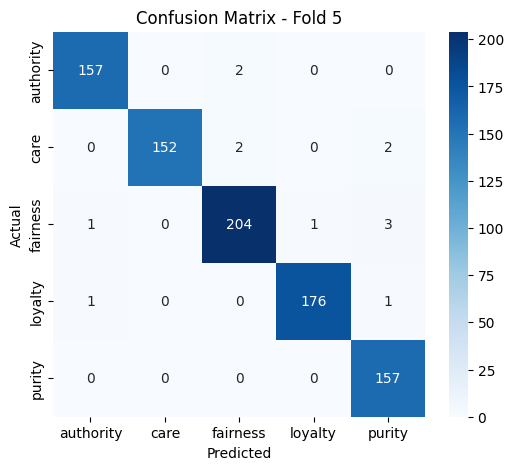


Misclassified Tweets:
 Tweet: "If there are to be North East specific #CAA rules, what happened to the One Nation, One Law motto that drove decisions in #Kashmir?" | True: 2 | Predicted: 4
 Tweet: "Dear Modi govt, withdraw present #CAA and if you must have it, redraft it substantially. Take out these words :Ã¢ÂÂHindu, Sikh, Buddhist, Jain, Parsi, Christian.Ã¢ÂÂ Replace with these words: Ã¢ÂÂpersecuted religious minorities.Ã¢ÂÂ #CAA_NRC_Protests" | True: 0 | Predicted: 2
 Tweet: "Our democracy should remain pure and free from any technological manipulation. Trust in elections is paramount! #SaveDemocracy" | True: 2 | Predicted: 4
 Tweet: "The debate over EVMs continues, but transparency and audits can help ensure trust. #ElectionReforms" | True: 1 | Predicted: 2
 Tweet: "While some see Animal Sacrifices as devotion, others view them as cruelty. Perspectives matter." | True: 1 | Predicted: 4

Fold 6/7


Epoch,Training Loss,Validation Loss
1,0.346300,0.061562
2,0.092500,0.051023
3,0.000500,0.055683


Fold 6 - Accuracy: 0.9895, Precision: 0.9897, Recall: 0.9895, F1-score: 0.9895
Misclassifications per Class (Actual → Predicted):
[[0 1 1 0 1]
 [0 0 0 0 0]
 [1 3 0 0 0]
 [0 1 0 0 0]
 [0 0 0 1 0]]


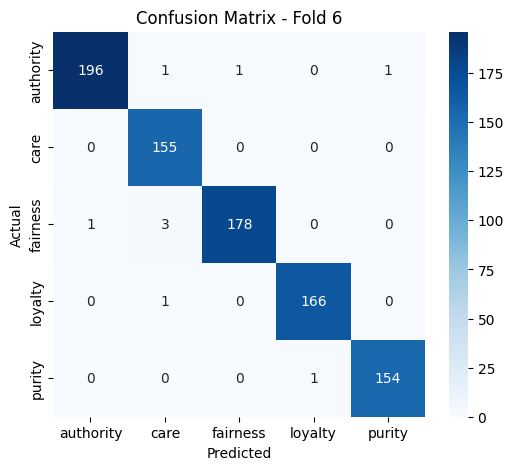


Misclassified Tweets:
 Tweet: "So its Clear now Protest against #CAA is not for Political/Democratic Reason it's Ghazwa-E-Hind,Anti Hindu and Pure Fanatic Islamic Movement." | True: 4 | Predicted: 3
 Tweet: "Bengaluru Church organising protest against #CAA which allows oppressed Christians to get Indian citizenship..

What to say!!!" | True: 3 | Predicted: 1
 Tweet: "Without a verifiable paper trail, EVMs can never be fully trusted. Bring back ballot papers! #EVMScam" | True: 2 | Predicted: 1
 Tweet: "Religious traditions and modern animal rights often clash over sacrificial practices." | True: 0 | Predicted: 1
 Tweet: "Religious traditions and modern animal rights often clash over sacrificial practices." | True: 2 | Predicted: 1

Fold 7/7


Epoch,Training Loss,Validation Loss
1,0.001800,0.054206
2,0.087500,0.046415
3,0.000700,0.041959


Fold 7 - Accuracy: 0.9918, Precision: 0.9919, Recall: 0.9918, F1-score: 0.9918
Misclassifications per Class (Actual → Predicted):
[[0 1 0 1 0]
 [0 0 0 0 1]
 [0 0 0 1 0]
 [0 0 0 0 0]
 [0 2 0 1 0]]


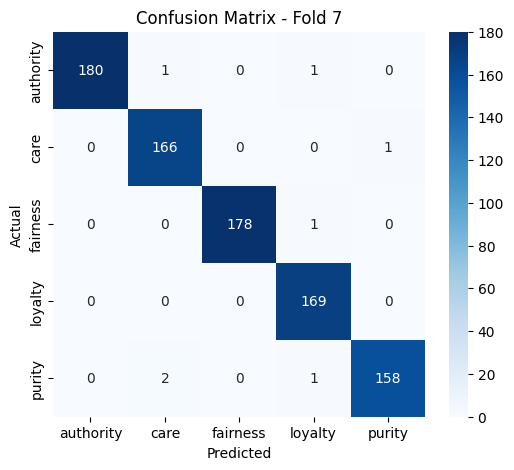


Misclassified Tweets:
 Tweet: "Woman protester breaks down while speaking to NDTV's Ravish Kumar at Delhi's #ShaheenBagh #CAA #NRC" | True: 1 | Predicted: 4
 Tweet: "Gender Identity Disorder was first set as a diagnosis in the Diagnostic Statistical Manual (used to diagnosis mental illnesses) in 1987. It was changed to Gender Dysphoria in 2013 to erase the stigma attached to the word Disorder. Note the prevalence rate. I wonder if some of those interesting studies have lapsed due to not wanting to find the biological, genetic, or psychological influences that may be causal and perhaps able to be addressed. Note the paragraph that advises the proper course of treatment to make sure the person is doing it for the right reason! And how much higher the success rate was. " | True: 0 | Predicted: 1
 Tweet: "True spirituality is about love, not bloodshed. #CompassionOverCruelty" | True: 4 | Predicted: 1
 Tweet: "Animal Sacrifices is an act of faith, passed down through generations. Let tradi

In [ ]:
# Perform K-Fold Cross-Validation on training data
k_fold_cross_validation(model, bert_train_dataset, k=7, batch_size=8, epochs=3, lr=2e-5, texts = text,label_encoder=  label_encoder)

In [ ]:
print(accuracies_main)

[[0.5925494761350407, 0.7764842840512224, 0.9429569266589057, 0.9825378346915018, 0.9848661233993015, 0.9895104895104895, 0.9918414918414918]]


# Tfidf with lstm
- The data set is limited(1207 Tweets).
- Data encoded using TF-IDF vectorizer and fed to lstm for classification
- Performing K(5 here) fold cross validation for analyzing the model

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, sequences, labels, vectorizer):
        self.sequences = vectorizer.transform(sequences).toarray()  # Transform text to numerical features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'features': torch.tensor(self.sequences[idx], dtype=torch.float32),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(LSTMClassifier, self).__init__()
        self.bilstm = nn.LSTM(input_dim, hidden_dim, batch_first=True,bidirectional = True)

        self.hidden1 = nn.Linear(hidden_dim*2, 128)
        self.hidden2 = nn.Linear(128, 64)
        self.hidden3 = nn.Linear(64, 32)
        self.classifier = nn.Linear(32, output_dim)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
      # Reshape input to (batch_size, sequence_length=1, input_size)
      x = x.unsqueeze(1)
      _, (hidden, _) = self.bilstm(x)
      hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)  # Concatenate the last two hidden states
      #output = self.dropout(hidden[-1])
      output = self.hidden1(hidden)
      output = self.dropout(output)
      output = self.hidden2(output)
      output = self.dropout(output)
      output = self.hidden3(output)
      output = self.dropout(output)
      return self.classifier(output)

In [ ]:
BiLstm_losses, BiLstm_accuracies, BiLstm_precisions, BiLstm_recalls, BiLstm_f1_scores = [], [], [], [], []

In [ ]:
def k_fold_cross_validation(model, dataset, texts, labels, k=7, batch_size=8, epochs=5, lr=1e-3):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(labels), y=labels)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

    accuracies, precisions, recalls, f1_scores = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
        print(f"\nFold {fold+1}/{k}")

        train_sampler = SubsetRandomSampler(train_idx)
        val_sampler = SubsetRandomSampler(val_idx)

        train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
        val_loader = DataLoader(dataset, batch_size=batch_size, sampler=val_sampler)

        for epoch in range(epochs):
            model.train()
            for batch in train_loader:
                optimizer.zero_grad()

                features = batch['features'].to(device)
                labels = batch['label'].to(device)

                outputs = model(features)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

            scheduler.step()

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                features = batch['features'].to(device)
                outputs = model(features)
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch['label'].cpu().numpy())

        accuracy = accuracy_score(all_labels, all_preds)
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted", zero_division=0)

        accuracies.append(accuracy)
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

        print(f"Fold {fold+1} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix for Fold {fold+1}')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()
        BiLstm_accuracies.append(accuracy)
        BiLstm_precisions.append(precision)
        BiLstm_recalls.append(recall)
        BiLstm_f1_scores.append(f1)
        BiLstm_losses.append(loss.)
    # Print Final Averages
    print(f"\nFinal Results Across {k} Folds:")
    print(f"Avg Accuracy: {np.mean(accuracies):.4f}")
    print(f"Avg Precision: {np.mean(precisions):.4f}")
    print(f"Avg Recall: {np.mean(recalls):.4f}")
    print(f"Avg F1-Score: {np.mean(f1_scores):.4f}")


In [ ]:
vectorizer = TfidfVectorizer(max_features=512)
features = vectorizer.fit_transform(X).toarray()
vocab = vectorizer.get_feature_names_out()

In [ ]:
input_dim = features.shape[1]
hidden_dim = 256
output_dim = 5

In [ ]:
print(input_dim)

512


In [ ]:
dataset = SentimentDataset(X, y, vectorizer)

In [ ]:
model = LSTMClassifier(input_dim, hidden_dim, output_dim)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

LSTMClassifier(
  (bilstm): LSTM(512, 256, batch_first=True, bidirectional=True)
  (hidden1): Linear(in_features=512, out_features=128, bias=True)
  (hidden2): Linear(in_features=128, out_features=64, bias=True)
  (hidden3): Linear(in_features=64, out_features=32, bias=True)
  (classifier): Linear(in_features=32, out_features=5, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


Fold 1/7
Fold 1 - Accuracy: 0.4843, Precision: 0.4921, Recall: 0.4843, F1-score: 0.4825


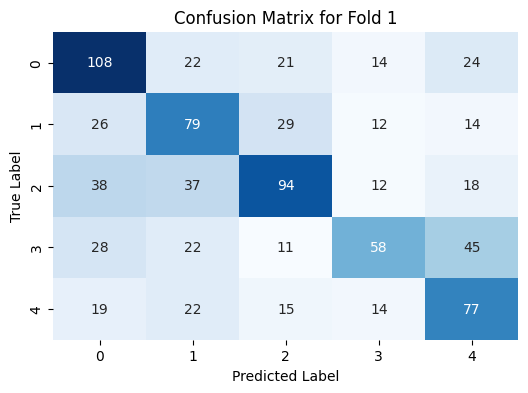


Fold 2/7
Fold 2 - Accuracy: 0.5879, Precision: 0.5900, Recall: 0.5879, F1-score: 0.5883


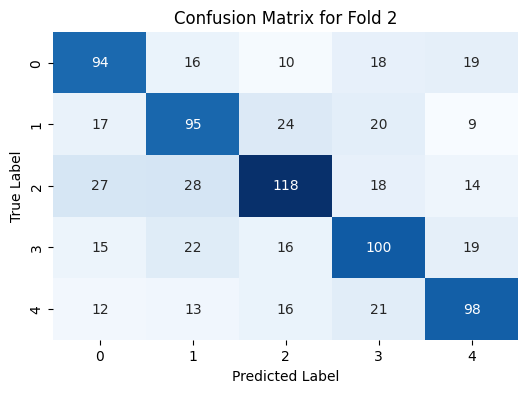


Fold 3/7
Fold 3 - Accuracy: 0.6531, Precision: 0.6560, Recall: 0.6531, F1-score: 0.6540


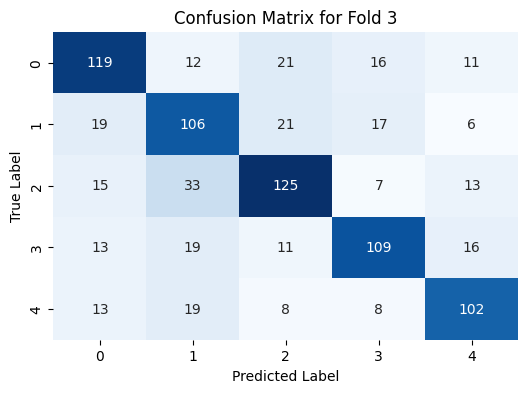


Fold 4/7
Fold 4 - Accuracy: 0.6461, Precision: 0.6492, Recall: 0.6461, F1-score: 0.6468


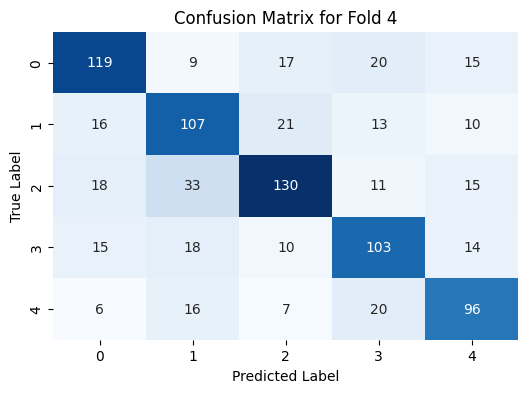


Fold 5/7
Fold 5 - Accuracy: 0.6647, Precision: 0.6671, Recall: 0.6647, F1-score: 0.6650


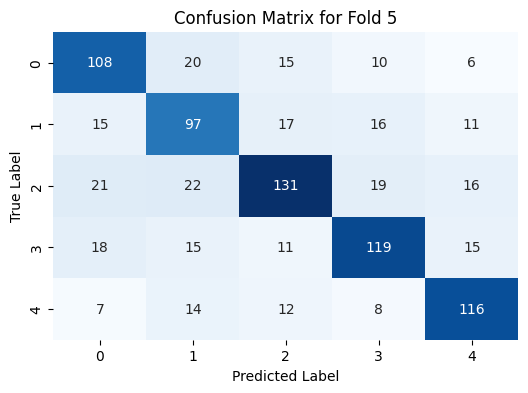


Fold 6/7
Fold 6 - Accuracy: 0.6667, Precision: 0.6658, Recall: 0.6667, F1-score: 0.6657


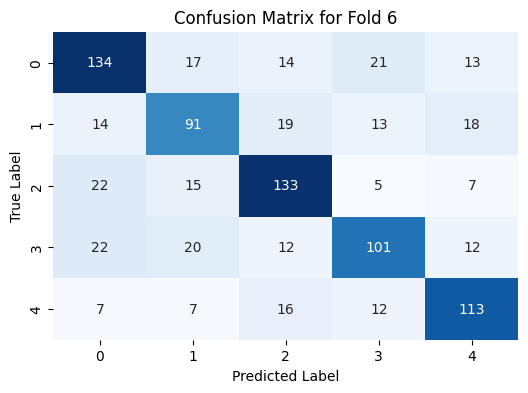


Fold 7/7
Fold 7 - Accuracy: 0.6550, Precision: 0.6568, Recall: 0.6550, F1-score: 0.6554


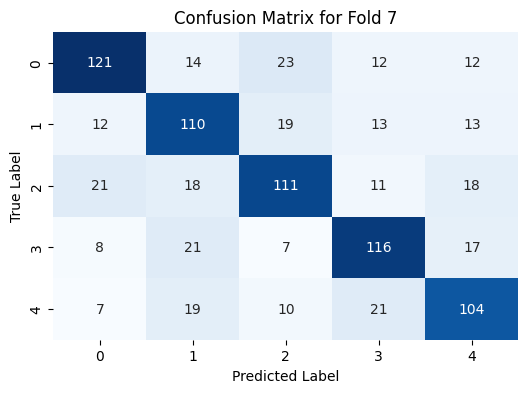


Final Results Across 7 Folds:
Avg Accuracy: 0.6225
Avg Precision: 0.6253
Avg Recall: 0.6225
Avg F1-Score: 0.6225


In [ ]:
k_fold_cross_validation(model, dataset, X, y)

In [ ]:
print(BiLstm_losses)

[tensor(0.9973, device='cuda:0', grad_fn=<NllLossBackward0>), tensor(1.0873, device='cuda:0', grad_fn=<NllLossBackward0>), tensor(0.8987, device='cuda:0', grad_fn=<NllLossBackward0>), tensor(0.6009, device='cuda:0', grad_fn=<NllLossBackward0>), tensor(1.3136, device='cuda:0', grad_fn=<NllLossBackward0>), tensor(0.8254, device='cuda:0', grad_fn=<NllLossBackward0>), tensor(0.0104, device='cuda:0', grad_fn=<NllLossBackward0>)]


#BIGRU model with Glove embeddings

In [ ]:
class GRUClassifier(nn.Module):
    def __init__(self, input_dim=300, hidden_dim=128, output_dim=3, num_layers=1, dropout=0.3):
        super(GRUClassifier, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, bidirectional=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)  # bi-directional
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        _, h_n = self.gru(x)
        h_n = torch.cat((h_n[-2], h_n[-1]), dim=1)
        out = self.dropout(h_n)
        return self.fc(out)

In [ ]:
def load_glove_embeddings(filepath, embedding_dim=300):
    embeddings = {}
    with open(filepath, 'r', encoding='utf-8') as file:
        for line in file:
            values = line.strip().split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings


In [ ]:
def sentence_to_embedding(sentence, word_to_vec, max_len=50, emb_dim=300):
    tokens = sentence.lower().split()
    embeddings = []

    for token in tokens[:max_len]:
        embeddings.append(word_to_vec.get(token, np.zeros(emb_dim)))
    while len(embeddings) < max_len:
        embeddings.append(np.zeros(emb_dim))

    return np.array(embeddings)

In [ ]:
def prepare_data(sentences, labels, word_to_vec, max_len=50, emb_dim=300):
    vectors = [sentence_to_embedding(s, word_to_vec, max_len, emb_dim) for s in sentences]
    return torch.tensor(np.stack(vectors)).float(), torch.tensor(labels)

In [ ]:
gru_losses, gru_accuracies, gru_precisions, gru_recalls, gru_f1_scores = [], [], [], [], []

In [ ]:
def k_fold_gru_cross_validation(model_class, X, y, texts, label_encoder, output_dim, k=7, batch_size=8, epochs=3, lr=1e-3):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    losses, accuracies, precisions, recalls, f1_scores = [], [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\nFold {fold+1}/{k}")

        # Subsets
        train_dataset = TensorDataset(X[train_idx], y[train_idx])
        val_dataset = TensorDataset(X[val_idx], y[val_idx])

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        # Model
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = model_class(output_dim=output_dim).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        # Training
        model.train()
        for epoch in range(epochs):
            epoch_loss = 0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                preds = model(xb)
                loss = criterion(preds, yb)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            print(f" Epoch {epoch+1} - Loss: {epoch_loss / len(train_loader):.4f}")

        # Evaluation
        model.eval()
        all_preds, all_labels = [], []
        misclassified_samples = []

        with torch.no_grad():
            for i, (xb, yb) in enumerate(val_loader):
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                predicted = torch.argmax(preds, dim=1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(yb.cpu().numpy())

                for j, (pred, true) in enumerate(zip(predicted, yb)):
                    if pred != true:
                        misclassified_samples.append((texts[val_idx[i * batch_size + j]], true.item(), pred.item()))

        acc = accuracy_score(all_labels, all_preds)
        prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted", zero_division=0)
        accuracies.append(acc)
        precisions.append(prec)
        recalls.append(rec)
        f1_scores.append(f1)

        print(f"Fold {fold+1} - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")
        gru_accuracies.append(acc)
        gru_precisions.append(prec)
        gru_recalls.append(rec)
        gru_f1_scores.append(f1)
        gru_losses.append(epoch_loss)
        # Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix - Fold {fold+1}")
        plt.show()

        print("\nMisclassified Tweets:")
        for text, true, pred in misclassified_samples[:5]:
            print(f" Tweet: \"{text}\" | True: {true} | Predicted: {pred}")

    # Final Results
    print(f"\nFinal Results Across {k} Folds:")
    print(f"Avg Accuracy: {np.mean(accuracies):.4f}")
    print(f"Avg Precision: {np.mean(precisions):.4f}")
    print(f"Avg Recall: {np.mean(recalls):.4f}")
    print(f"Avg F1-Score: {np.mean(f1_scores):.4f}")

In [10]:
import os
import requests
import zipfile

def download_glove(destination_folder="glove"):
    url = "http://nlp.stanford.edu/data/glove.6B.zip"
    zip_path = os.path.join(destination_folder, "glove.6B.zip")
    glove_txt_path = os.path.join(destination_folder, "glove.6B.300d.txt")

    os.makedirs(destination_folder, exist_ok=True)

    if not os.path.exists(glove_txt_path):
        print("Downloading GloVe embeddings...")
        response = requests.get(url, stream=True)
        with open(zip_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)

        print("Extracting GloVe embeddings...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(destination_folder)

        os.remove(zip_path)  # Clean up the zip file
        print("GloVe embeddings downloaded and extracted.")
    else:
        print("GloVe embeddings already exist.")

# Run the function
download_glove()

Extracting GloVe embeddings...
GloVe embeddings downloaded and extracted.


In [ ]:
word_to_vec = load_glove_embeddings("/content/glove/glove.6B.300d.txt")



In [ ]:
label_encoder = LabelEncoder()
label_list = label_encoder.fit_transform(y)
# Prepare data
X_tensor, y_tensor = prepare_data(X, label_list, word_to_vec)


Fold 1/7


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


 Epoch 1 - Loss: 1.3668
 Epoch 2 - Loss: 1.1733
 Epoch 3 - Loss: 1.0685
Fold 1 - Accuracy: 0.5017, Precision: 0.5081, Recall: 0.5017, F1: 0.5029


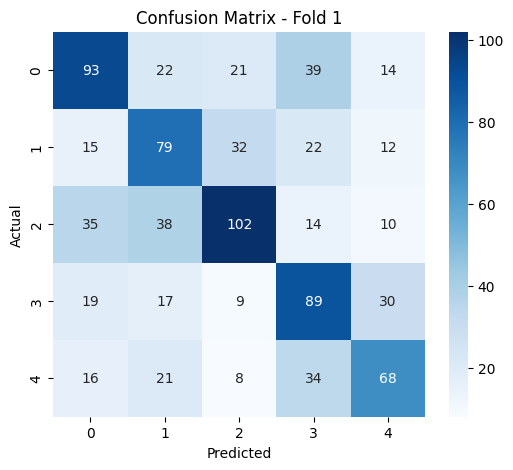


Misclassified Tweets:
 Tweet: "In the freezing cold of December, the women of Shaheen bagh keep vigil under blankets, their infants in a huddle under one arm, as men distribute chai and boiled eggs. It's 17th night of this women led vigil against #CAA #NRC. The Tiranga is at the centre #ShaheenBagh" | True: 1 | Predicted: 4
 Tweet: "Dark day for India. 

A religion-based citizenship test is antithetical to the secular constitutional foundations of the republic, and I will fight against this legally and politically with all my might.

#CAA #MNMagainstCAA #CAANotification" | True: 2 | Predicted: 4
 Tweet: "#EVM machines never refuse to dissapoint #MaharashtraElection2024 #Haryana" | True: 2 | Predicted: 0
 Tweet: "Modi himself raised serious concern about EVM during the 2014 LS election. What happened to his stand now ? Will the media share this clip to Modi ask his stand ?@narendramodi #EVM" | True: 0 | Predicted: 1
 Tweet: "Retired IAS #Kannan_Gopinathan  tells u why it's necessary to

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


 Epoch 1 - Loss: 1.3446
 Epoch 2 - Loss: 1.1623
 Epoch 3 - Loss: 1.0691
Fold 2 - Accuracy: 0.4854, Precision: 0.4973, Recall: 0.4854, F1: 0.4828


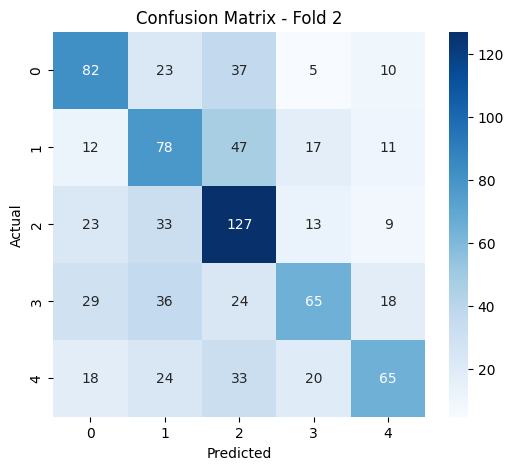


Misclassified Tweets:
 Tweet: "Ã¢ÂÂBJPÃ¢ÂÂs vision, only televisionÃ¢ÂÂ.... so now they are claiming & dreaming to rule for the next 50 years... seems like they have full confidence in their EVM strategy, that is, Election Via Mischief. *#EVM #ElectionViaMischief*" | True: 4 | Predicted: 2
 Tweet: "Competing priorities, political realities and delicate balancing between whatÃ¢ÂÂs immediately possible and what could potentially disrupt peace and progress made so far.

#CAA took a while, saw widespread protests and #ShaheenBagh. It didnÃ¢ÂÂt concern a single Indian Muslim." | True: 2 | Predicted: 3
 Tweet: "Occupying PoK is a fancy idea but what about PoK Muslims? 

We canÃ¢ÂÂt give them citizenship now as #CAA is already in force." | True: 1 | Predicted: 3
 Tweet: "Don't ask who I am 

#uniform_civil_code 
No Caste based reservations" | True: 4 | Predicted: 2
 Tweet: "Pmk strictly opposes Uniform civil code. 
@draramadoss


#PMK #ANBUMANI #RAMADOSS #UCC  #Uniform_Civil_Code

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


 Epoch 1 - Loss: 1.3545
 Epoch 2 - Loss: 1.1736
 Epoch 3 - Loss: 1.0678
Fold 3 - Accuracy: 0.5239, Precision: 0.5346, Recall: 0.5239, F1: 0.5242


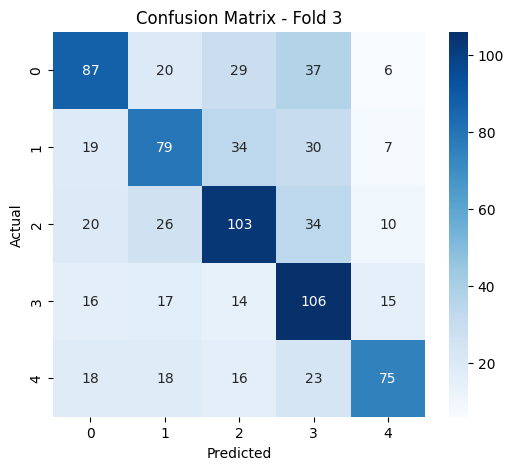


Misclassified Tweets:
 Tweet: "Big difference between booth capturing and EVM fraud: Booth capturing can be caught and fixed. EVM fraud can go unnoticed and can't be solved #EVM" | True: 0 | Predicted: 3
 Tweet: "At this rate, soon #EVM's will be on Amazon and Flipkart." | True: 2 | Predicted: 3
 Tweet: "If you win, Democracy wins. But If you loose, Blame EVMs. BJP @BJP4India has never raised concerns about the reliability of EVMs or questioned the integrity of the Election Commission of India. 
@ECISVEEP #EVM" | True: 0 | Predicted: 3
 Tweet: "Head constable of Delhi Police  Ratan Lal dies as violent clashes escalate between pro and anti #CAA protesters in North East Delhi. Horrifying news. And a day after ultimatum by Kapil Mishra that all protests have to be cleared or else.. Whoever responsible must be arrested now" | True: 1 | Predicted: 0
 Tweet: "Does this Mor0n even understand what #CAA is?" | True: 0 | Predicted: 2

Fold 4/7


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


 Epoch 1 - Loss: 1.3538
 Epoch 2 - Loss: 1.1667
 Epoch 3 - Loss: 1.0739
Fold 4 - Accuracy: 0.5250, Precision: 0.5353, Recall: 0.5250, F1: 0.5261


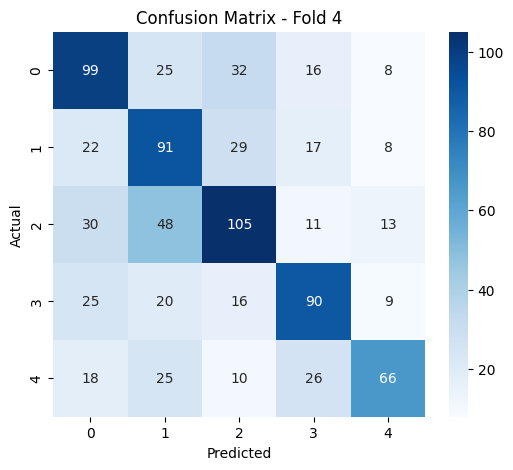


Misclassified Tweets:
 Tweet: "#EVMs are easy to manipulate . This was demonstrated by the #BJP in 2009 !" | True: 2 | Predicted: 0
 Tweet: "Madhya Pradesh: A protestor pulls hair of Rajgarh Deputy Collector Priya Verma, after she hits BJP workers and drags them. The clash broke out during a demonstration in support of #CAA." | True: 2 | Predicted: 4
 Tweet: "We are raising our voice against the confusion surrounding #EVMs that has emerged among the people of the state." | True: 2 | Predicted: 0
 Tweet: "Dear Modi govt, withdraw present #CAA and if you must have it, redraft it substantially. Take out these words :Ã¢ÂÂHindu, Sikh, Buddhist, Jain, Parsi, Christian.Ã¢ÂÂ Replace with these words: Ã¢ÂÂpersecuted religious minorities.Ã¢ÂÂ Ã°ÂÂÂ#CAA_NRC_Protests" | True: 2 | Predicted: 0
 Tweet: " invited Owaisi Saheb for debate on #UCC but he blocked me. 

He don't want One to One Debate 

#UniformCivilCode 
@blsanthosh" | True: 3 | Predicted: 2

Fold 5/7


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


 Epoch 1 - Loss: 1.3600
 Epoch 2 - Loss: 1.1702
 Epoch 3 - Loss: 1.0776
Fold 5 - Accuracy: 0.5239, Precision: 0.5302, Recall: 0.5239, F1: 0.5224


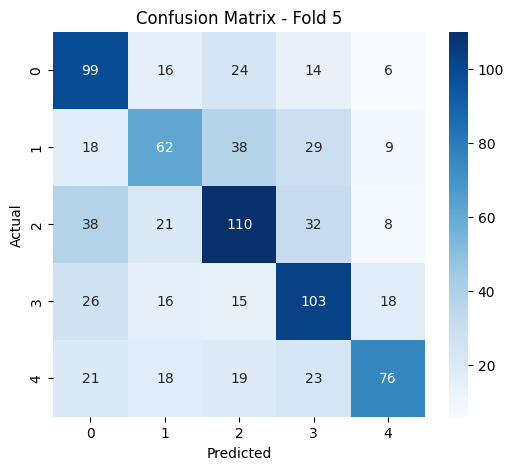


Misclassified Tweets:
 Tweet: "Congress leader Mani Shankar Aiyar at the protest against #CAA & #NRC, in Delhi's Shaheen Bagh" | True: 2 | Predicted: 0
 Tweet: "Students have contacted us from Jyoti Nivas college in Bangalore and told us they were threatened to support #CAA or "face consequences like JNU"- this happened outside their college gates. Hope relevant authorities are taking note" | True: 2 | Predicted: 3
 Tweet: "I strongly feel #Modi did use some Pegasus type of malware to manipulate #EVM during 2019 elections. " | True: 0 | Predicted: 2
 Tweet: "Broad daylight kidnapping of a girl in #BJP ruled #Rajasthan state Difficult to believe that the #BJP party enjoys popular mandates. Why would people ever vote for such rogues?
#EVM Manipulation?" | True: 2 | Predicted: 0
 Tweet: "Vote rigging takes place in VVPAT also.Many organizations, intellectuals, lawyers are raising voice to ban #EVM. 
Even honest officers are resigning, still why is the Supreme Court not banning #EVM?" | T

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


 Epoch 1 - Loss: 1.3541
 Epoch 2 - Loss: 1.1690
 Epoch 3 - Loss: 1.0762
Fold 6 - Accuracy: 0.5198, Precision: 0.5203, Recall: 0.5198, F1: 0.5167


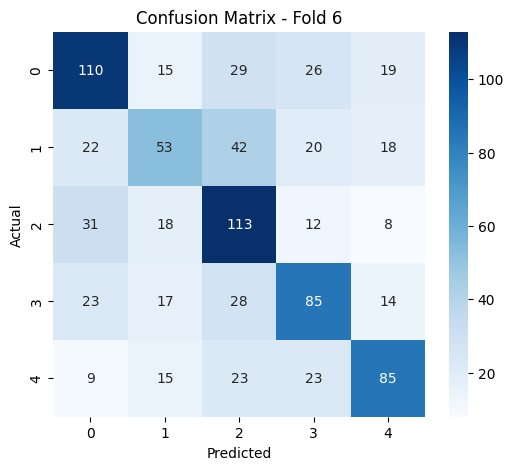


Misclassified Tweets:
 Tweet: "Congratulations
CAA  is arrived  #CAA" | True: 3 | Predicted: 0
 Tweet: "My dear Indian muslims we are 35 crores of population in india if we get united each & every politician & hindutvawadis will become useless

Remember the #caa protests" | True: 3 | Predicted: 1
 Tweet: "This guy was part of anti Hindu protests in the name of #CAA in which many Hindus were kiIIed.

Today he's enjoying celebrity life!!!!" | True: 2 | Predicted: 3
 Tweet: "The only person likely to believe all these #EVM hacking stories is Rahul Gandhi." | True: 3 | Predicted: 2
 Tweet: "When are they going to blame #EVM?#ElectionResults #VictoryForEknathSinde #Mahayuti" | True: 3 | Predicted: 2

Fold 7/7


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


 Epoch 1 - Loss: 1.3608
 Epoch 2 - Loss: 1.1735
 Epoch 3 - Loss: 1.0740
Fold 7 - Accuracy: 0.5186, Precision: 0.5460, Recall: 0.5186, F1: 0.5172


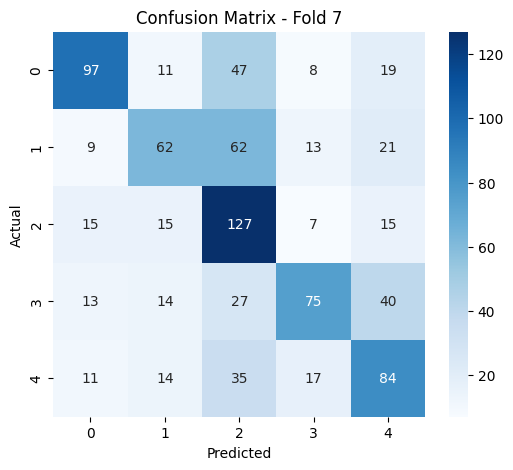


Misclassified Tweets:
 Tweet: "Meanwhile the Shiv Sena still doesnÃ¢ÂÂt know what #CAA is all about 
They are just toeing what Ã¢ÂÂSonia AmmaÃ¢ÂÂ says them to toe " | True: 3 | Predicted: 0
 Tweet: "Leftist Propaganda Portal The Wire spreads fake news on Ã¢ÂÂmismatchedÃ¢ÂÂ voters count in Maharashtra elections, but later deletes it when the Chief electoral officer of Maharashtra exposes them #EVM #MaharashtraElection2024" | True: 4 | Predicted: 3
 Tweet: "I will not provide documents for #CAA. 

Who is Amit Shah and Narendra Modi to determine my Indianness ? 

#CAB #CAA" | True: 2 | Predicted: 0
 Tweet: "Gender is a spectrum. Let's create a world where all gender identities are respected" | True: 1 | Predicted: 4
 Tweet: "MAN MADE a film by T Cooper
A feature-length documentary tracing the varied lives of four transgender men, as they prepare to step on stage at the only all-trans bodybuilding competition in the world." | True: 1 | Predicted: 4

Final Results Across 7 Folds:

In [ ]:
k_fold_gru_cross_validation(
    model_class=GRUClassifier,
    X=X_tensor,
    y=y_tensor,
    texts=X,
    label_encoder=label_encoder,
    output_dim=len(label_encoder.classes_)
)

#TFIDF with GRU

In [ ]:
# Label Encoding
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)



In [ ]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X).toarray()



In [ ]:
# Reshape TF-IDF into pseudo-sequence format
timesteps = 10
features_per_step = X_tfidf.shape[1] // timesteps
X_seq = X_tfidf[:, :timesteps * features_per_step].reshape(-1, timesteps, features_per_step)



In [ ]:
X_tensor = torch.tensor(X_seq, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)



In [ ]:
# 2. Define GRU Model
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_dim):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_dim)

    def forward(self, x):
        _, h_n = self.gru(x)
        return self.fc(h_n.squeeze(0))

# 3. K-Fold Cross Validation



In [ ]:
GRU_2_losses,GRU_2_accuracies,GRU_2_precisions,GRU_2_recalls,GRU_2_f1_scores = [],[],[],[],[]

In [ ]:
def k_fold_gru_cross_validation(model_class, X, y, texts, label_encoder, output_dim,
                                 k=7, batch_size=16, epochs=3, lr=2e-3):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    losses, accuracies, precisions, recalls, f1_scores = [], [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\nFold {fold+1}/{k}")

        # Data subsets
        train_dataset = TensorDataset(X[train_idx], y[train_idx])
        val_dataset = TensorDataset(X[val_idx], y[val_idx])

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        # Model setup
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = model_class(input_size=X.shape[2], hidden_size=64, output_dim=output_dim).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        # Training
        model.train()
        for epoch in range(epochs):
            epoch_loss = 0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                preds = model(xb)
                loss = criterion(preds, yb)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()
            print(f" Epoch {epoch+1} - Loss: {epoch_loss / len(train_loader):.4f}")

        # Evaluation
        model.eval()
        all_preds, all_labels = [], []
        misclassified_samples = []

        with torch.no_grad():
            for i, (xb, yb) in enumerate(val_loader):
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                predicted = torch.argmax(preds, dim=1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(yb.cpu().numpy())

                for j, (pred, true) in enumerate(zip(predicted, yb)):
                    if pred != true:
                        misclassified_samples.append((texts[val_idx[i * batch_size + j]], true.item(), pred.item()))

        acc = accuracy_score(all_labels, all_preds)
        prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted", zero_division=0)
        accuracies.append(acc)
        precisions.append(prec)
        recalls.append(rec)
        f1_scores.append(f1)

        print(f"Fold {fold+1} - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")
        GRU_2_accuracies.append(acc)
        GRU_2_precisions.append(prec)
        GRU_2_recalls.append(rec)
        GRU_2_f1_scores.append(f1)
        GRU_2_losses.append(epoch_loss)
        # Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix - Fold {fold+1}")
        plt.show()

        print("\nMisclassified Tweets:")
        for text, true, pred in misclassified_samples[:5]:
            print(f" Tweet: \"{text}\" | True: {true} | Predicted: {pred}")

    # Final Results
    print(f"\nFinal Results Across {k} Folds:")
    print(f"Avg Accuracy: {np.mean(accuracies):.4f}")
    print(f"Avg Precision: {np.mean(precisions):.4f}")
    print(f"Avg Recall: {np.mean(recalls):.4f}")
    print(f"Avg F1-Score: {np.mean(f1_scores):.4f}")




Fold 1/7
 Epoch 1 - Loss: 1.5855
 Epoch 2 - Loss: 1.3619
 Epoch 3 - Loss: 1.1707
Fold 1 - Accuracy: 0.4668, Precision: 0.4714, Recall: 0.4668, F1: 0.4618


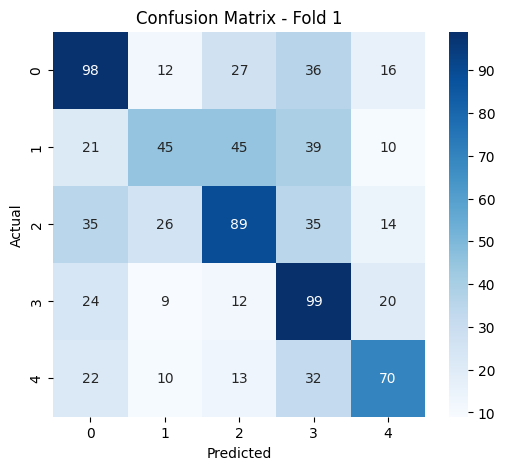


Misclassified Tweets:
 Tweet: "In the freezing cold of December, the women of Shaheen bagh keep vigil under blankets, their infants in a huddle under one arm, as men distribute chai and boiled eggs. It's 17th night of this women led vigil against #CAA #NRC. The Tiranga is at the centre #ShaheenBagh" | True: 1 | Predicted: 0
 Tweet: "Dark day for India. 

A religion-based citizenship test is antithetical to the secular constitutional foundations of the republic, and I will fight against this legally and politically with all my might.

#CAA #MNMagainstCAA #CAANotification" | True: 2 | Predicted: 4
 Tweet: "#EVM machines never refuse to dissapoint #MaharashtraElection2024 #Haryana" | True: 2 | Predicted: 0
 Tweet: "Modi himself raised serious concern about EVM during the 2014 LS election. What happened to his stand now ? Will the media share this clip to Modi ask his stand ?@narendramodi #EVM" | True: 0 | Predicted: 3
 Tweet: "In my POV, If BJP could really manipulate  #EVM, they would h

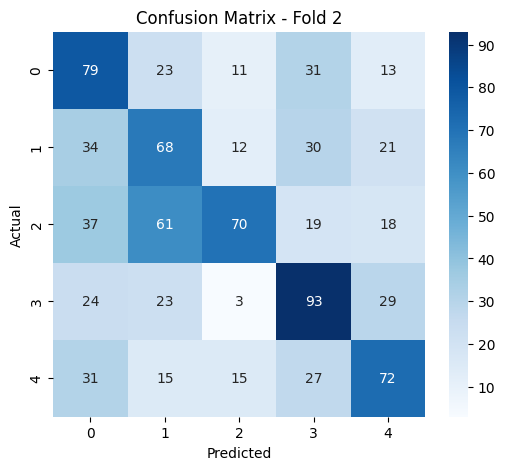


Misclassified Tweets:
 Tweet: "Kapil Mishra, BJP on violence in North East Delhi: I appeal to everyone to stop violence as it will not lead to any solution. Whether it is people who are supporting #CAA or those who are against it, I appeal everyone to maintain peace. Delhi's brotherhood should remain intact." | True: 3 | Predicted: 1
 Tweet: "Ã¢ÂÂBJPÃ¢ÂÂs vision, only televisionÃ¢ÂÂ.... so now they are claiming & dreaming to rule for the next 50 years... seems like they have full confidence in their EVM strategy, that is, Election Via Mischief. *#EVM #ElectionViaMischief*" | True: 4 | Predicted: 0
 Tweet: "#EVM is cheating with voters, with democracy. Paper ballot is only transparent way #BanEVM" | True: 2 | Predicted: 1
 Tweet: "Anyone spreading fake news and rumors about #CAA will face strict legal action. This law doesn't revoke anyone's citizenship, and it isn't against any religion or faith.

Be a responsible citizen, know the truth, and beware of fake news." | True: 0 | Pr

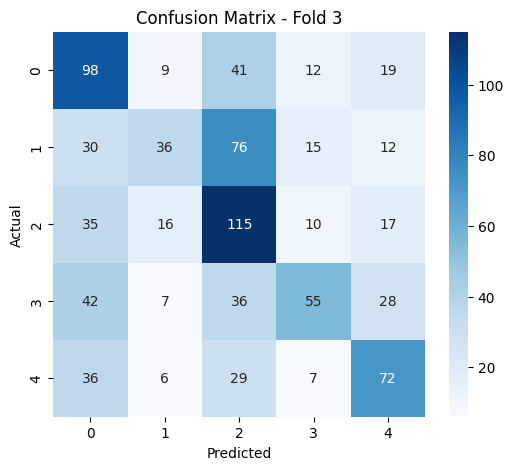


Misclassified Tweets:
 Tweet: "Ppl standing in Rain to welcome PM Modi in kerala. Then the lobby questions #ModiMagic to #EVM ." | True: 3 | Predicted: 0
 Tweet: "Big difference between booth capturing and EVM fraud: Booth capturing can be caught and fixed. EVM fraud can go unnoticed and can't be solved #EVM" | True: 0 | Predicted: 1
 Tweet: "At this rate, soon #EVM's will be on Amazon and Flipkart." | True: 2 | Predicted: 3
 Tweet: "Head constable of Delhi Police  Ratan Lal dies as violent clashes escalate between pro and anti #CAA protesters in North East Delhi. Horrifying news. And a day after ultimatum by Kapil Mishra that all protests have to be cleared or else.. Whoever responsible must be arrested now" | True: 1 | Predicted: 0
 Tweet: "Prime Minister 
@narendramodi
 angrily says there has been no talk of nationwide NRC except Supreme Court mandated #NRC in Assam. But this sir is not true. The Home Minister has clearly referenced it. All you need to say is that there is NO NRC f

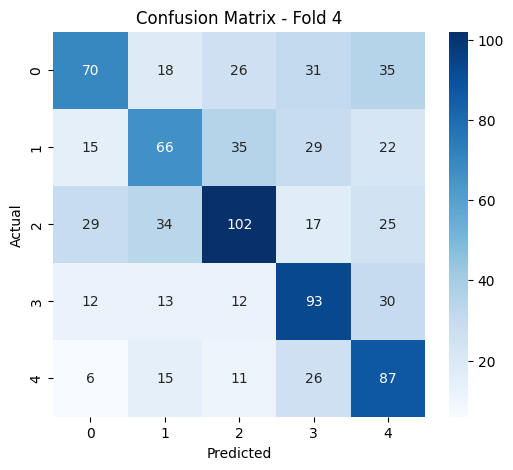


Misclassified Tweets:
 Tweet: "#EVMs are easy to manipulate . This was demonstrated by the #BJP in 2009 !" | True: 2 | Predicted: 4
 Tweet: "Delhi with #CAA
@narendramodi
 
Delhi with 
@AmitShah" | True: 3 | Predicted: 0
 Tweet: "Madhya Pradesh: A protestor pulls hair of Rajgarh Deputy Collector Priya Verma, after she hits BJP workers and drags them. The clash broke out during a demonstration in support of #CAA." | True: 2 | Predicted: 0
 Tweet: "We are raising our voice against the confusion surrounding #EVMs that has emerged among the people of the state." | True: 2 | Predicted: 0
 Tweet: "Dear Modi govt, withdraw present #CAA and if you must have it, redraft it substantially. Take out these words :Ã¢ÂÂHindu, Sikh, Buddhist, Jain, Parsi, Christian.Ã¢ÂÂ Replace with these words: Ã¢ÂÂpersecuted religious minorities.Ã¢ÂÂ Ã°ÂÂÂ#CAA_NRC_Protests" | True: 2 | Predicted: 1

Fold 5/7
 Epoch 1 - Loss: 1.5868
 Epoch 2 - Loss: 1.3846
 Epoch 3 - Loss: 1.2050
Fold 5 - Accuracy: 0.4552

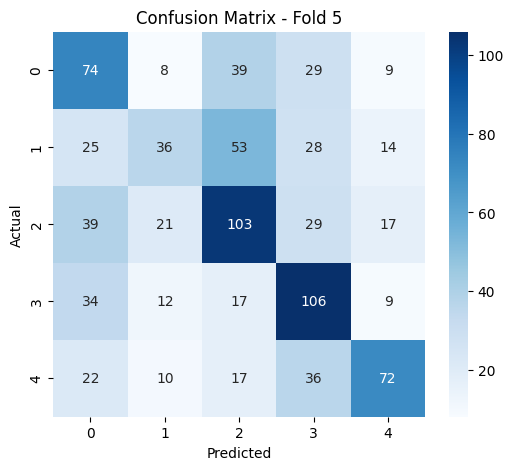


Misclassified Tweets:
 Tweet: "Congress leader Mani Shankar Aiyar at the protest against #CAA & #NRC, in Delhi's Shaheen Bagh" | True: 2 | Predicted: 0
 Tweet: "Students have contacted us from Jyoti Nivas college in Bangalore and told us they were threatened to support #CAA or "face consequences like JNU"- this happened outside their college gates. Hope relevant authorities are taking note" | True: 2 | Predicted: 3
 Tweet: "I strongly feel #Modi did use some Pegasus type of malware to manipulate #EVM during 2019 elections. " | True: 0 | Predicted: 2
 Tweet: "Broad daylight kidnapping of a girl in #BJP ruled #Rajasthan state Difficult to believe that the #BJP party enjoys popular mandates. Why would people ever vote for such rogues?
#EVM Manipulation?" | True: 2 | Predicted: 0
 Tweet: "If there are to be North East specific #CAA rules, what happened to the One Nation, One Law motto that drove decisions in #Kashmir?" | True: 2 | Predicted: 0

Fold 6/7
 Epoch 1 - Loss: 1.5877
 Epoch 2 - 

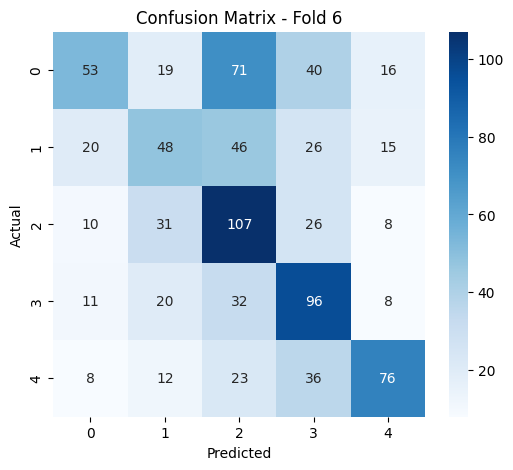


Misclassified Tweets:
 Tweet: "My dear Indian muslims we are 35 crores of population in india if we get united each & every politician & hindutvawadis will become useless

Remember the #caa protests" | True: 3 | Predicted: 1
 Tweet: "This guy was part of anti Hindu protests in the name of #CAA in which many Hindus were kiIIed.

Today he's enjoying celebrity life!!!!" | True: 2 | Predicted: 3
 Tweet: "When are they going to blame #EVM?#ElectionResults #VictoryForEknathSinde #Mahayuti" | True: 3 | Predicted: 2
 Tweet: "Interacted with students of 
@iimtnoida
 in morning. Must Say Youth is well informed about #CAA & fake narrative build around it ." | True: 0 | Predicted: 2
 Tweet: "The World is watching.India is protesting 
@narendramodi
 
@AmitShah
 Repeal the #CAA. Stop trying to silence us. 
#NoViolenceButNoSilence" | True: 2 | Predicted: 3

Fold 7/7
 Epoch 1 - Loss: 1.5912
 Epoch 2 - Loss: 1.3715
 Epoch 3 - Loss: 1.1749
Fold 7 - Accuracy: 0.4674, Precision: 0.4930, Recall: 0.4674, F

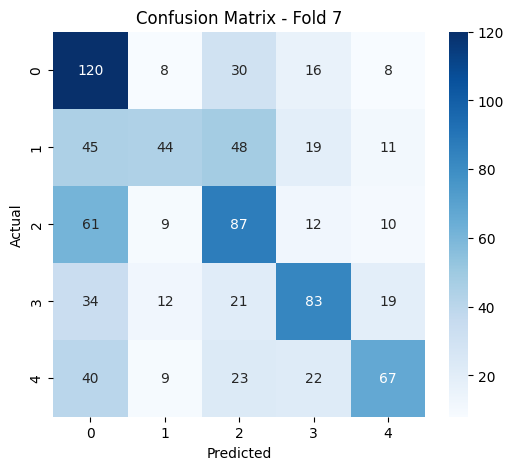


Misclassified Tweets:
 Tweet: "Woman protester breaks down while speaking to NDTV's Ravish Kumar at Delhi's #ShaheenBagh #CAA #NRC" | True: 1 | Predicted: 4
 Tweet: "Meanwhile the Shiv Sena still doesnÃ¢ÂÂt know what #CAA is all about 
They are just toeing what Ã¢ÂÂSonia AmmaÃ¢ÂÂ says them to toe " | True: 3 | Predicted: 2
 Tweet: "Do you still believe #EVM's are hacked?" | True: 2 | Predicted: 0
 Tweet: "Leftist Propaganda Portal The Wire spreads fake news on Ã¢ÂÂmismatchedÃ¢ÂÂ voters count in Maharashtra elections, but later deletes it when the Chief electoral officer of Maharashtra exposes them #EVM #MaharashtraElection2024" | True: 4 | Predicted: 0
 Tweet: "I will not provide documents for #CAA. 

Who is Amit Shah and Narendra Modi to determine my Indianness ? 

#CAB #CAA" | True: 2 | Predicted: 0

Final Results Across 7 Folds:
Avg Accuracy: 0.4573
Avg Precision: 0.4733
Avg Recall: 0.4573
Avg F1-Score: 0.4516


In [ ]:
# Run the cross-validation
k_fold_gru_cross_validation(GRUModel, X_tensor, y_tensor, X, label_encoder, output_dim=num_classes)

In [ ]:
# Sample folds (replace with actual ones)
GRU_2_folds = list(range(1, len(GRU_2_losses) + 1))
gru_folds = list(range(1, len(gru_losses) + 1))
BiLstm_folds = list(range(1, len(BiLstm_losses) + 1))
main_folds = list(range(1, len(losses_main) + 1))

# Flexible plotting function
def plot_variable_folds(metrics_with_folds, labels, title, ylabel):
    plt.figure(figsize=(10, 6))
    for (folds, metric), label in zip(metrics_with_folds, labels):
        plt.plot(folds, metric, marker='o', label=label)
    plt.title(title)
    plt.xlabel("Fold")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.ylim(0, 1 if "Loss" not in ylabel else None)
    plt.show()



In [ ]:
# Labels
model_labels = [
    "GRU (TF-IDF)",
    "GRU (GloVe 300d)",
    "BiLSTM (GloVe 300d)",
    "BERT Base Uncased"
]



In [ ]:
len(losses_main)

1

In [ ]:
a = []
for i in losses_main[0]:
    a.append(i)
losses_main = a

for i in accuracies_main[0]:
    a.append(i)
accuracies_main = a

for i in precisions_main[0]:
    a.append(i)
precisions_main = a

for i in recalls_main[0]:
    a.append(i)
recalls_main = a

TypeError: 'float' object is not iterable

In [ ]:
a = []
for i in BiLstm_losses:
  a.append(i.item())
BiLstm_losses = a


[688.1163599491119,
 688.4713853001595,
 687.6412152349949,
 691.6111504435539,
 693.9566640555859,
 694.1592199653387,
 692.7301039993763]

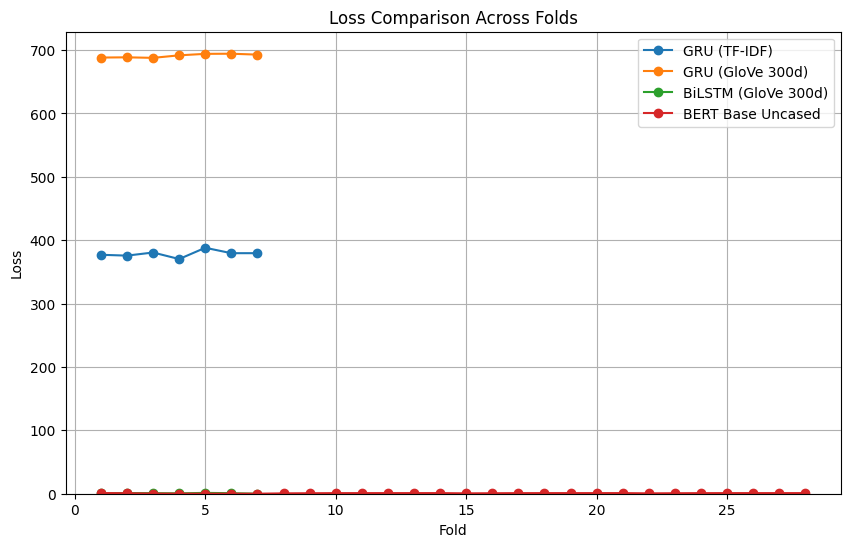

ValueError: x and y must have same first dimension, but have shapes (7,) and (15,)

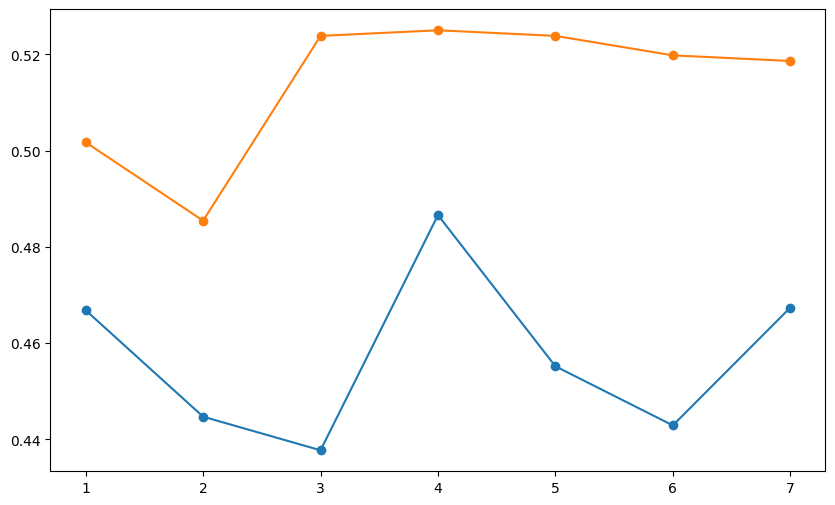

In [ ]:
# Generate plots with (folds, metrics) pairs
plot_variable_folds(
    [(GRU_2_folds, GRU_2_losses), (gru_folds, gru_losses), (BiLstm_folds, BiLstm_losses), (main_folds, losses_main)],
    model_labels, "Loss Comparison Across Folds", "Loss"
)

plot_variable_folds(
    [(GRU_2_folds, GRU_2_accuracies), (gru_folds, gru_accuracies), (BiLstm_folds, BiLstm_accuracies), (main_folds, accuracies_main)],
    model_labels, "Accuracy Comparison Across Folds", "Accuracy"
)

plot_variable_folds(
    [(GRU_2_folds, GRU_2_precisions), (gru_folds, gru_precisions), (BiLstm_folds, BiLstm_precisions), (main_folds, precisions_main)],
    model_labels, "Precision Comparison Across Folds", "Precision"
)

plot_variable_folds(
    [(GRU_2_folds, GRU_2_recalls), (gru_folds, gru_recalls), (BiLstm_folds, BiLstm_recalls), (main_folds, recalls_main)],
    model_labels, "Recall Comparison Across Folds", "Recall"
)

plot_variable_folds(
    [(GRU_2_folds, GRU_2_f1_scores), (gru_folds, gru_f1_scores), (BiLstm_folds, BiLstm_f1_scores), (main_folds, f1_scores_main)],
    model_labels, "F1 Score Comparison Across Folds", "F1 Score"
)

# LSTM with GLOVE embeddings

In [11]:
def load_glove_embeddings(glove_file_path, embedding_dim=300):
    word_to_vec = {}
    with open(glove_file_path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            word_to_vec[word] = vector
    return word_to_vec


In [12]:
def sentence_to_embedding(sentence, word_to_vec, max_len=50, emb_dim=300):
    tokens = sentence.lower().split()
    embeddings = [word_to_vec.get(token, np.zeros(emb_dim)) for token in tokens[:max_len]]
    while len(embeddings) < max_len:
        embeddings.append(np.zeros(emb_dim))
    return np.array(embeddings)

In [13]:
def prepare_data(sentences, labels, word_to_vec, max_len=50, emb_dim=300):
    vectors = [sentence_to_embedding(s, word_to_vec, max_len, emb_dim) for s in sentences]
    return torch.tensor(np.stack(vectors)).float(), torch.tensor(labels)

In [14]:
class SentimentDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


In [15]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(LSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(hidden_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.output = nn.Linear(32, output_dim)

    def forward(self, x):
        hidden, _ = self.lstm(x)
        hidden = hidden[:,-1,:]  # last hidden state
        x = self.dropout(hidden)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        x = torch.relu(self.fc3(x))
        return self.output(x)


In [16]:
def k_fold_lstm_cross_validation(model_class, X, y, texts,lr, label_encoder, output_dim,
                                 k=5, batch_size=8, epochs=3, hidden_dim=256, input_dim=300):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    accuracies, precisions, recalls, f1_scores = [], [], [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        print(f"\nFold {fold+1}/{k}")

        train_dataset = TensorDataset(X[train_idx], y[train_idx])
        val_dataset = TensorDataset(X[val_idx], y[val_idx])

        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = model_class(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.1)
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)
        # Training
        model.train()
        for epoch in range(epochs):
            total_loss = 0
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                preds = model(xb)
                loss = criterion(preds, yb)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            print(f" Epoch {epoch+1} - Loss: {total_loss / len(train_loader):.4f}")
            scheduler.step()
        # Evaluation
        model.eval()
        all_preds, all_labels = [], []
        misclassified_samples = []

        with torch.no_grad():
            for i, (xb, yb) in enumerate(val_loader):
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                predicted = torch.argmax(preds, dim=1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(yb.cpu().numpy())
                for j, (pred, true) in enumerate(zip(predicted, yb)):
                    if pred != true:
                        misclassified_samples.append((texts[val_idx[i * batch_size + j]], true.item(), pred.item()))

        acc = accuracy_score(all_labels, all_preds)
        prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted", zero_division=0)
        accuracies.append(acc)
        precisions.append(prec)
        recalls.append(rec)
        f1_scores.append(f1)

        print(f"Fold {fold+1} - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix - Fold {fold+1}")
        plt.show()

        print("\nMisclassified Tweets:")
        for text, true, pred in misclassified_samples[:5]:
            print(f" Tweet: \"{text}\" | True: {true} | Predicted: {pred}")

    print(f"\nFinal Results Across {k} Folds:")
    print(f"Avg Accuracy: {np.mean(accuracies):.4f}")
    print(f"Avg Precision: {np.mean(precisions):.4f}")
    print(f"Avg Recall: {np.mean(recalls):.4f}")
    print(f"Avg F1-Score: {np.mean(f1_scores):.4f}")

In [19]:
glove_path = "glove/glove.6B.300d.txt"

word_to_vec = load_glove_embeddings(glove_path, embedding_dim=300)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
X_tensor, y_tensor = prepare_data(X, y_encoded, word_to_vec, max_len=100, emb_dim=300)


Fold 1/5
 Epoch 1 - Loss: 1.6109
 Epoch 2 - Loss: 1.6084
 Epoch 3 - Loss: 1.6075
Fold 1 - Accuracy: 0.2336, Precision: 0.0546, Recall: 0.2336, F1: 0.0885


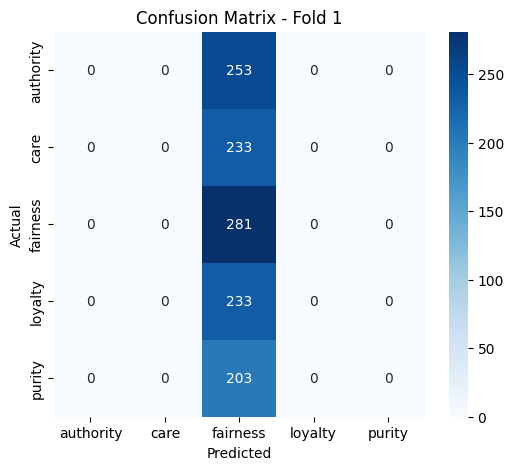


Misclassified Tweets:
 Tweet: "In the freezing cold of December, the women of Shaheen bagh keep vigil under blankets, their infants in a huddle under one arm, as men distribute chai and boiled eggs. It's 17th night of this women led vigil against #CAA #NRC. The Tiranga is at the centre #ShaheenBagh" | True: 1 | Predicted: 2
 Tweet: "Modi himself raised serious concern about EVM during the 2014 LS election. What happened to his stand now ? Will the media share this clip to Modi ask his stand ?@narendramodi #EVM" | True: 0 | Predicted: 2
 Tweet: "Retired IAS #Kannan_Gopinathan  tells u why it's necessary to ban #EVM's.Earlier, by pressing the button of #EVM, vote went directly to the CU & now #VVPAT is  in between.
Vote rigging happens in the VVPAT only. Why is the SC  not banning #EVM's ?" | True: 0 | Predicted: 2
 Tweet: "I have spent about 60 years in the forefront of #electronics, #telecom,IT, #software, #complex systems and a lot more. I have studied #EVM system carefully and belie

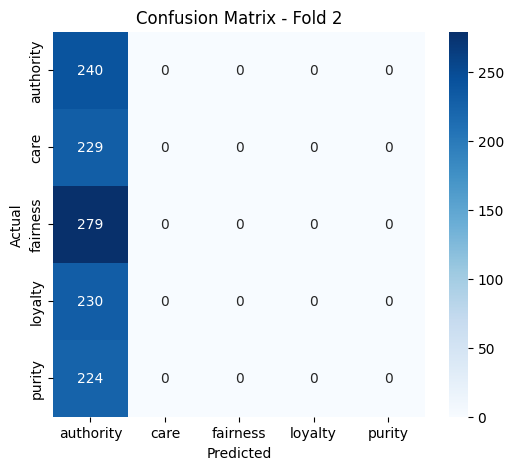


Misclassified Tweets:
 Tweet: "Kapil Mishra, BJP on violence in North East Delhi: I appeal to everyone to stop violence as it will not lead to any solution. Whether it is people who are supporting #CAA or those who are against it, I appeal everyone to maintain peace. Delhi's brotherhood should remain intact." | True: 3 | Predicted: 0
 Tweet: "Ppl standing in Rain to welcome PM Modi in kerala. Then the lobby questions #ModiMagic to #EVM ." | True: 3 | Predicted: 0
 Tweet: "At this rate, soon #EVM's will be on Amazon and Flipkart." | True: 2 | Predicted: 0
 Tweet: "Ã¢ÂÂBJPÃ¢ÂÂs vision, only televisionÃ¢ÂÂ.... so now they are claiming & dreaming to rule for the next 50 years... seems like they have full confidence in their EVM strategy, that is, Election Via Mischief. *#EVM #ElectionViaMischief*" | True: 4 | Predicted: 0
 Tweet: "Head constable of Delhi Police  Ratan Lal dies as violent clashes escalate between pro and anti #CAA protesters in North East Delhi. Horrifying news. And 

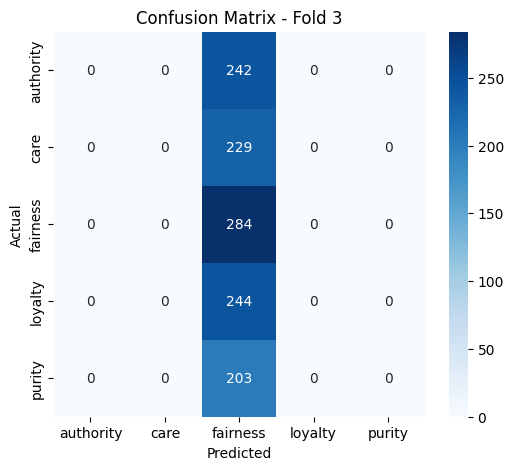


Misclassified Tweets:
 Tweet: "Delhi with #CAA
@narendramodi
 
Delhi with 
@AmitShah" | True: 3 | Predicted: 2
 Tweet: "Big difference between booth capturing and EVM fraud: Booth capturing can be caught and fixed. EVM fraud can go unnoticed and can't be solved #EVM" | True: 0 | Predicted: 2
 Tweet: "#CAA is meant to provide fast track citizenship to non-Muslim families from Afghanistan, Pakistan and Bangladesh that have been lynched, raped and persecuted for generations due to their religious beliefs. 

Whatever side youÃ¢ÂÂre on, make sure itÃ¢ÂÂs the compassionate one." | True: 1 | Predicted: 2
 Tweet: "Prime Minister 
@narendramodi
 angrily says there has been no talk of nationwide NRC except Supreme Court mandated #NRC in Assam. But this sir is not true. The Home Minister has clearly referenced it. All you need to say is that there is NO NRC for India #CAA #NRC #RamlilaMaidan" | True: 0 | Predicted: 2
 Tweet: "Does this Mor0n even understand what #CAA is?" | True: 0 | Predict

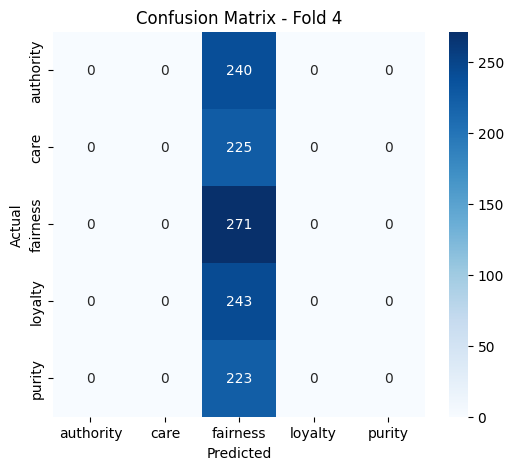


Misclassified Tweets:
 Tweet: "Congratulations
CAA  is arrived  #CAA" | True: 3 | Predicted: 2
 Tweet: "My dear Indian muslims we are 35 crores of population in india if we get united each & every politician & hindutvawadis will become useless

Remember the #caa protests" | True: 3 | Predicted: 2
 Tweet: "IÃ¢ÂÂm an Indian Muslim and I welcome #CAA" | True: 3 | Predicted: 2
 Tweet: "I strongly feel #Modi did use some Pegasus type of malware to manipulate #EVM during 2019 elections. " | True: 0 | Predicted: 2
 Tweet: "The only person likely to believe all these #EVM hacking stories is Rahul Gandhi." | True: 3 | Predicted: 2

Fold 5/5
 Epoch 1 - Loss: 1.6108
 Epoch 2 - Loss: 1.6081
 Epoch 3 - Loss: 1.6070
Fold 5 - Accuracy: 0.2155, Precision: 0.0464, Recall: 0.2155, F1: 0.0764


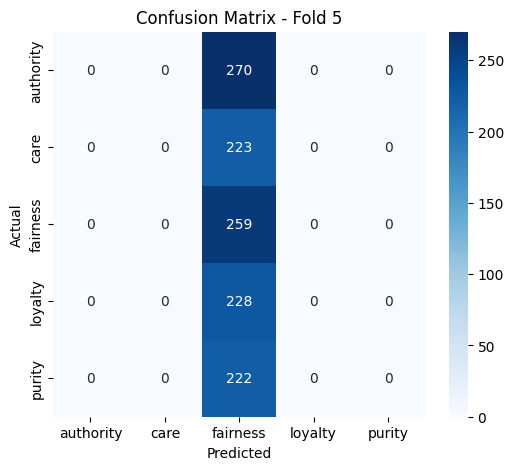


Misclassified Tweets:
 Tweet: "Woman protester breaks down while speaking to NDTV's Ravish Kumar at Delhi's #ShaheenBagh #CAA #NRC" | True: 1 | Predicted: 2
 Tweet: "So its Clear now Protest against #CAA is not for Political/Democratic Reason it's Ghazwa-E-Hind,Anti Hindu and Pure Fanatic Islamic Movement." | True: 4 | Predicted: 2
 Tweet: "Meanwhile the Shiv Sena still doesnÃ¢ÂÂt know what #CAA is all about 
They are just toeing what Ã¢ÂÂSonia AmmaÃ¢ÂÂ says them to toe " | True: 3 | Predicted: 2
 Tweet: "Leftist Propaganda Portal The Wire spreads fake news on Ã¢ÂÂmismatchedÃ¢ÂÂ voters count in Maharashtra elections, but later deletes it when the Chief electoral officer of Maharashtra exposes them #EVM #MaharashtraElection2024" | True: 4 | Predicted: 2
 Tweet: "Dear 
@DelhiPolice
, as a citizen, I urge you to take action against the journalists who are spreading unverified news & vile rumors through online platforms, social media, Whatsapp etc. on #CAA. Nobody should be abov

In [20]:
k_fold_lstm_cross_validation(
    model_class=LSTMClassifier,
    X=X_tensor,
    y=y_tensor,
    texts=X,
    label_encoder=label_encoder,
    output_dim=len(label_encoder.classes_),
    k=5,
    batch_size=8,
    epochs=3,
    lr=5e-4,
    hidden_dim=256,
    input_dim=300
)